Lucky Singh
202401100300146

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
img_size = 224
batch_size = 32

dataset_path = "datasets/Brain_tumor"

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_size, img_size),
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.
Classes: ['no', 'yes']


In [2]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

c:\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 497ms/step - accuracy: 0.4975 - loss: 399.4324 - val_accuracy: 0.3600 - val_loss: 20.6860
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 413ms/step - accuracy: 0.6059 - loss: 5.4294 - val_accuracy: 0.7400 - val_loss: 1.3795
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 412ms/step - accuracy: 0.7488 - loss: 0.6012 - val_accuracy: 0.7800 - val_loss: 0.7751
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 440ms/step - accuracy: 0.8227 - loss: 0.3782 - val_accuracy: 0.7600 - val_loss: 0.6587
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 443ms/step - accuracy: 0.8522 - loss: 0.2815 - val_accuracy: 0.8000 - val_loss: 0.8160
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 438ms/step - accuracy: 0.9458 - loss: 0.1389 - val_accuracy: 0.7000 - val_loss: 0.9779
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 414ms/step - accuracy: 0.9803 - loss: 0.0732 - val_accuracy: 0.8400 - val_loss: 1.5706
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 438ms/step - accuracy: 0.9803 - loss: 0.0819 - val_accuracy: 0.7800 - val_lo

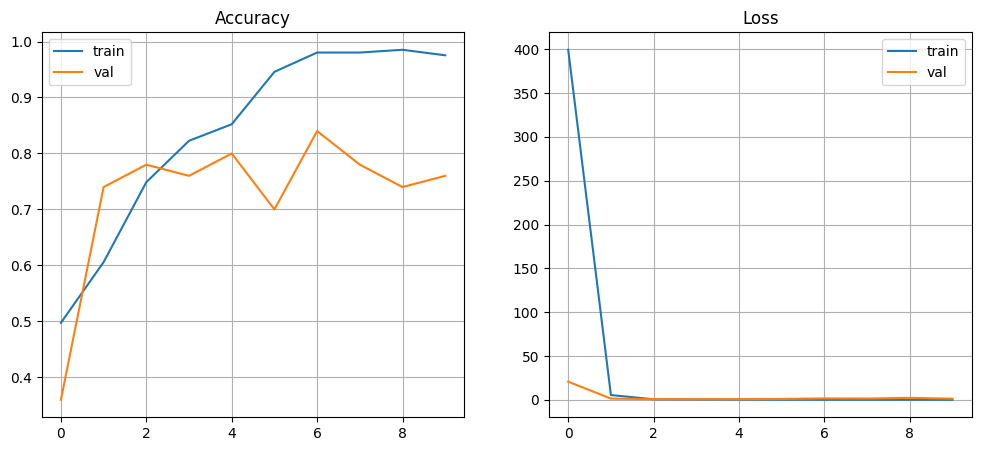

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.7600 - loss: 1.2473
Loss: 1.2473, Accuracy: 75.99999905%


In [17]:
fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1)
ax1.plot(history.history['accuracy'], label='train')
ax1.plot(history.history['val_accuracy'], label='val')
ax1.legend()
ax1.grid()
ax1.set_title("Accuracy")

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(history.history['loss'], label='train')
ax2.plot(history.history['val_loss'], label='val')
ax2.legend()
ax2.grid()
ax2.set_title("Loss")

plt.show()

loss , accu = model.evaluate(val_ds, batch_size=batch_size)

print(f"Loss: {loss:.4f}, Accuracy: {accu*100:.8f}%")